In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from openai import OpenAI
client = OpenAI("insert API here")  #i used an env file for OPENAI_API_KEY 
OPENAI_MODEL = "gpt-4o-mini" 

In [8]:
def ask_openai(system_msg: str, user_msg: str) -> str:
    """Call OpenAI Chat Completions and return the assistant text."""
    resp = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg},
        ],
        temperature=0.3,
    )
    return resp.choices[0].message.content.strip()

In [ ]:
df = pd.read_csv("train.csv") 


In [ ]:
#data exploration
missing = df.isna().sum().sort_values(ascending=False)
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['fare'] = df['fare'].fillna(df['fare'].median())
df['cabin'] = df['cabin'].fillna("Unknown")

In [ ]:
# feature engineering
df['familysize'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['familysize'] == 1).astype(int)

def extract_title(name):
    try:
        return name.split(',')[1].split('.')[0].strip()
    except Exception:
        return "Unknown"
df['title'] = df['name'].apply(extract_title)

age_bins = [0, 12, 18, 35, 55, 120]
age_labels = ['child', 'teen', 'adult', 'midage', 'senior']
df['agegroup'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

In [ ]:

num_cols = ['age', 'fare', 'sibsp', 'parch', 'familysize']
summary = df[num_cols].agg(['mean','median','std']).T.round(2)

def rate(groupby_cols): #function to calculate survival rate
    g = (df
         .groupby(groupby_cols, dropna=False)['survived']
         .agg(['mean','count'])
         .rename(columns={'mean':'survival_rate','count':'n'})
         .reset_index())
    g['survival_rate'] = g['survival_rate'].round(3)
    return g.sort_values('survival_rate', ascending=False)

by_sex = rate(['sex'])
by_pclass = rate(['pclass'])
by_agegroup = rate(['agegroup'])
by_sex_pclass = rate(['sex','pclass'])
by_embarked = rate(['embarked'])

corr = df[['survived','age','fare','sibsp','parch','familysize']].corr(numeric_only=True).round(2)

llm_table = (df
             .groupby(['sex','pclass'], dropna=False)
             .agg(Avg_Age=('age','mean'),
                  Avg_Fare=('fare','mean'),
                  Survival_Rate=('survived','mean'),
                  N=('survived','size'))
             .reset_index())
llm_table['Avg_Age'] = llm_table['Avg_Age'].round
llm_table['Avg_Fare'] = llm_table['Avg_Fare'].round
llm_table['Survival_Rate'] = llm_table['Survival_Rate'].round(3)

def to_markdown_table(pdf: pd.DataFrame) -> str:
    return "| " + " | ".join(pdf.columns) + " |\n" + \
           "| " + " | ".join(["---"]*len(pdf.columns)) + " |\n" + \
           "\n".join(["| " + " | ".join(map(str, row)) + " |" for row in pdf.values])


C:\Users\sokra\AppData\Local\Temp\ipykernel_27096\3579497396.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(groupby_cols, dropna=False)['survived']


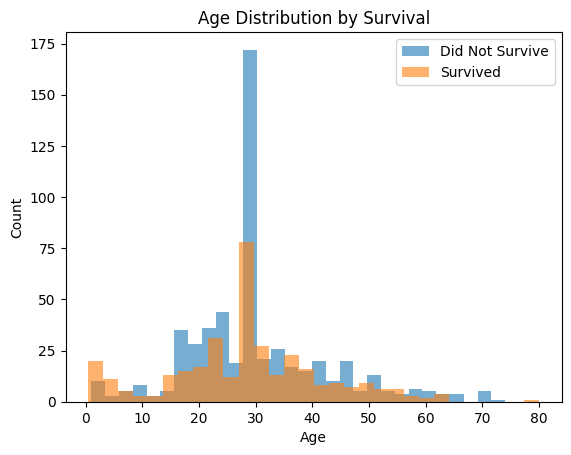

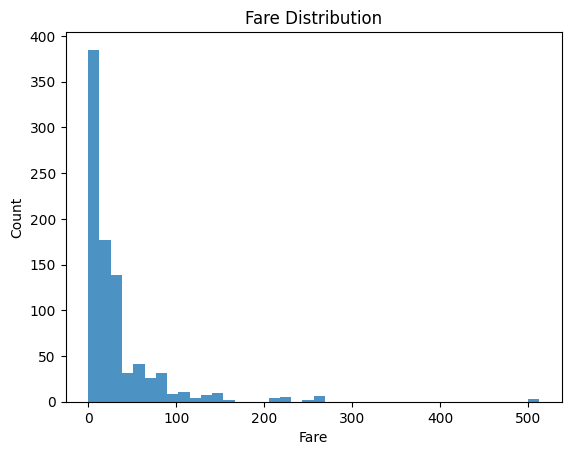

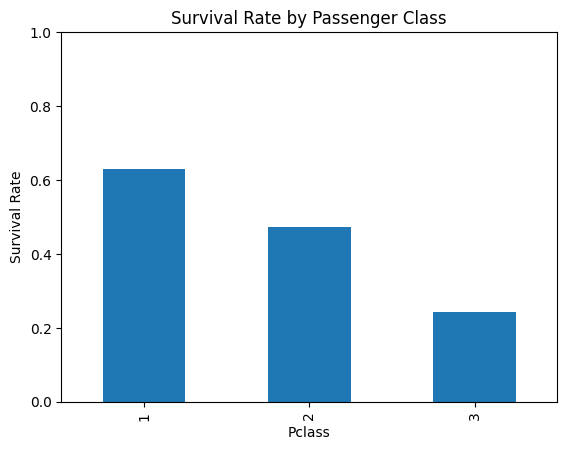

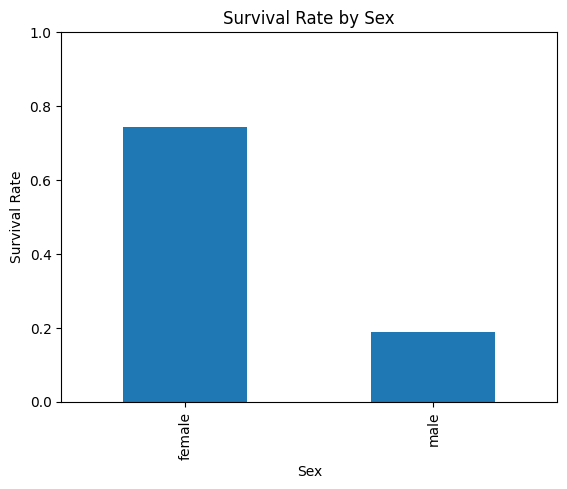

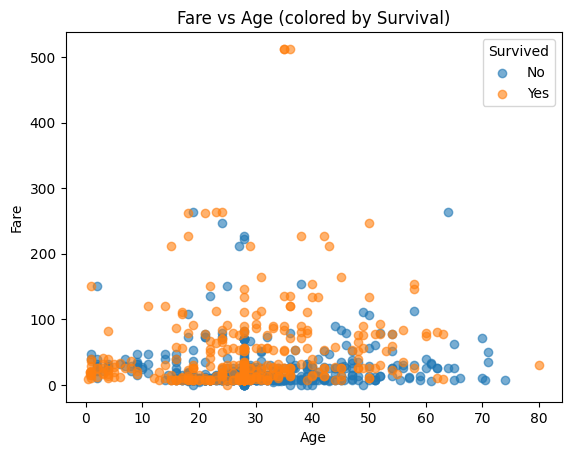

In [14]:
plt.figure()
df[df['survived']==0]['age'].plot(kind='hist', bins=30, alpha=0.6)
df[df['survived']==1]['age'].plot(kind='hist', bins=30, alpha=0.6)
plt.title("Age Distribution by Survival")
plt.xlabel("Age"); plt.ylabel("Count")
plt.legend(["Did Not Survive","Survived"])
plt.show()

plt.figure()
df['fare'].plot(kind='hist', bins=40, alpha=0.8)
plt.title("Fare Distribution")
plt.xlabel("Fare"); plt.ylabel("Count")
plt.show()

sr_pclass = df.groupby('pclass')['survived'].mean().round(3)
plt.figure()
sr_pclass.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Pclass"); plt.ylabel("Survival Rate"); plt.ylim(0,1)
plt.show()

sr_sex = df.groupby('sex')['survived'].mean().round(3)
plt.figure()
sr_sex.plot(kind='bar')
plt.title("Survival Rate by Sex")
plt.xlabel("Sex"); plt.ylabel("Survival Rate"); plt.ylim(0,1)
plt.show()

plt.figure()
plt.scatter(df[df['survived']==0]['age'], df[df['survived']==0]['fare'], alpha=0.6, label='No')
plt.scatter(df[df['survived']==1]['age'], df[df['survived']==1]['fare'], alpha=0.6, label='Yes')
plt.title("Fare vs Age (colored by Survival)")
plt.xlabel("Age"); plt.ylabel("Fare")
plt.legend(title="Survived")
plt.show()

In [ ]:
table_md = to_markdown_table(llm_table[['sex','pclass','Avg_Age','Avg_Fare','Survival_Rate','N']])

system_prompt = (
    "youre a data analyst. Write insights, non-speculative"
    "from the tables and notes. use plain languages, not too complicated" \
    
)

user_prompt = f"""
Context:
- Goal =  Summarize survival patterns in the Titanic training data.
- Note= 'Survival_Rate' is the fraction of passengers in that group that survived.
- Additional numeric context (correlations rounded): {corr['survived'].to_dict()}

Table (sex × pclass):
{table_md}

Please produce:
1) a short summary of 2-3 sentences.
2) Which passenger group had the highest survival rate?
3) Are there any unusual patterns in fare vs age?
4) Suggest a new feature or visualization to explore survival trends.
"""

openai_report = ask_openai(system_prompt, user_prompt)

print(openai_report)


print("\n=== Local Quick Takes ===")
print("Numeric summary:\n", summary)
print("\nSurvival by sex:\n", by_sex)
print("\nSurvival by pclass:\n", by_pclass)
print("\nSurvival by agegroup:\n", by_agegroup)
print("\nTop (sex × pclass) group by survival:\n", by_sex_pclass.head(3))
print("\nCorrelation matrix:\n", corr)


### Summary
The Titanic training data reveals notable differences in survival rates based on sex and passenger class (pclass). Female passengers had significantly higher survival rates compared to male passengers, particularly in first and second class.

### Insights
1. **Survival by Sex and Class**: Female passengers in first class had a survival rate of 96.8%, while males in the same class had only a 36.9% survival rate. This trend continues across all classes, with females consistently faring better than males.
2. **Age and Fare Influence**: The average age of female passengers decreases as class decreases, while the average fare also drops. Males show a similar trend, but their survival rates are much lower, indicating that factors like class and gender heavily influenced survival.
3. **Overall Survival Rates**: The overall survival rate for females is much higher than for males, suggesting that gender played a critical role in survival during the Titanic disaster.

### Drawbacks
1